<a href="https://colab.research.google.com/github/santausd/usd_project/blob/main/AAI_531_Project_5_1_workbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Setup Instructions

In [ ]:
!pip install -q ucimlrepo

In [ ]:
%%writefile requirements.txt
lightgbm
matplotlib
numpy
pandas
seaborn
tqdm
BlackBoxAuditing
aif360[Reductions,inFairness]

Writing requirements.txt


In [ ]:
!pip install -q -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 20.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.9/228.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
 

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.algorithms.preprocessing import Reweighing
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, accuracy_score
from aif360.metrics import ClassificationMetric
import lightgbm as lgb
from lightgbm import LGBMClassifier
from tqdm import tqdm
from aif360.algorithms.preprocessing import DisparateImpactRemover
import warnings
warnings.filterwarnings("ignore")

/usr/local/lib/python3.11/dist-packages/inFairness/utils/ndcg.py:37: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  vect_normalized_discounted_cumulative_gain = vmap(
/usr/local/lib/python3.11/dist-packages/inFairness/utils/ndcg.py:48: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  monte_carlo_vect_ndcg = vmap(vect_normalized_discounted

In [ ]:
#added later.
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier


##Create Dataset

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
adult = fetch_ucirepo(id=2)

# data (as pandas dataframes)
adult_dataset_org = adult.data.features
income_dataset_org = adult.data.targets

# metadata
#print(adult.metadata)

# variable information
#print(adult.variables)

In [ ]:
#Data clean up
# missing values check
adult_dataset_org = pd.concat([adult_dataset_org,income_dataset_org],  axis=1)
categorical_cols = adult_dataset_org.select_dtypes(include=['object', 'category']).columns
print(categorical_cols.tolist())

for column in categorical_cols:
  adult_dataset_org[column].replace('?' , np.nan, inplace = True)

missing_values = adult_dataset_org.isnull().sum()
#print("Missing values:\n", missing_values)
adult_dataset = adult_dataset_org.dropna()
#adult_dataset.isnull().sum()


['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']


In [ ]:
adult_dataset['income'].replace({'<=50K.': "<=50K", '>50K.': ">50K"}, inplace = True)

In [ ]:
adult_dataset['income'].value_counts()

,count
income,
<=50K,34014
>50K,11208


##Data Visualisation and clean up

In [ ]:
def plot_histograms(data, columns, nrows, ncols):
    """
    Plots histograms in a grid layout.
    """

    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 15))  # Adjust figsize as needed

    # Flatten the axes array for easier iteration
    axes = axes.flatten()

    for i, column in enumerate(columns):
        ax = axes[i]  # Get the current subplot
        uniques= list(sorted(data[column].dropna().unique()))
        #counts = [data[data[column] == value].shape[0] for value in uniques]
        size = len(uniques)
        xcoords = list(range(0, size))

        ax.hist(data[column], edgecolor='black')
        ax.set_xlabel(column)
        ax.set_ylabel('Frequency')
        ax.set_title(f'Histogram of {column}')
        plt.sca(ax)
        plt.xticks(xcoords, uniques, rotation='vertical' if size >= 5 else 'horizontal')

    # Remove any unused subplots
    for i in range(len(columns), nrows * ncols):
        fig.delaxes(axes[i])

    plt.tight_layout()  # Adjust spacing between subplots
    plt.show()


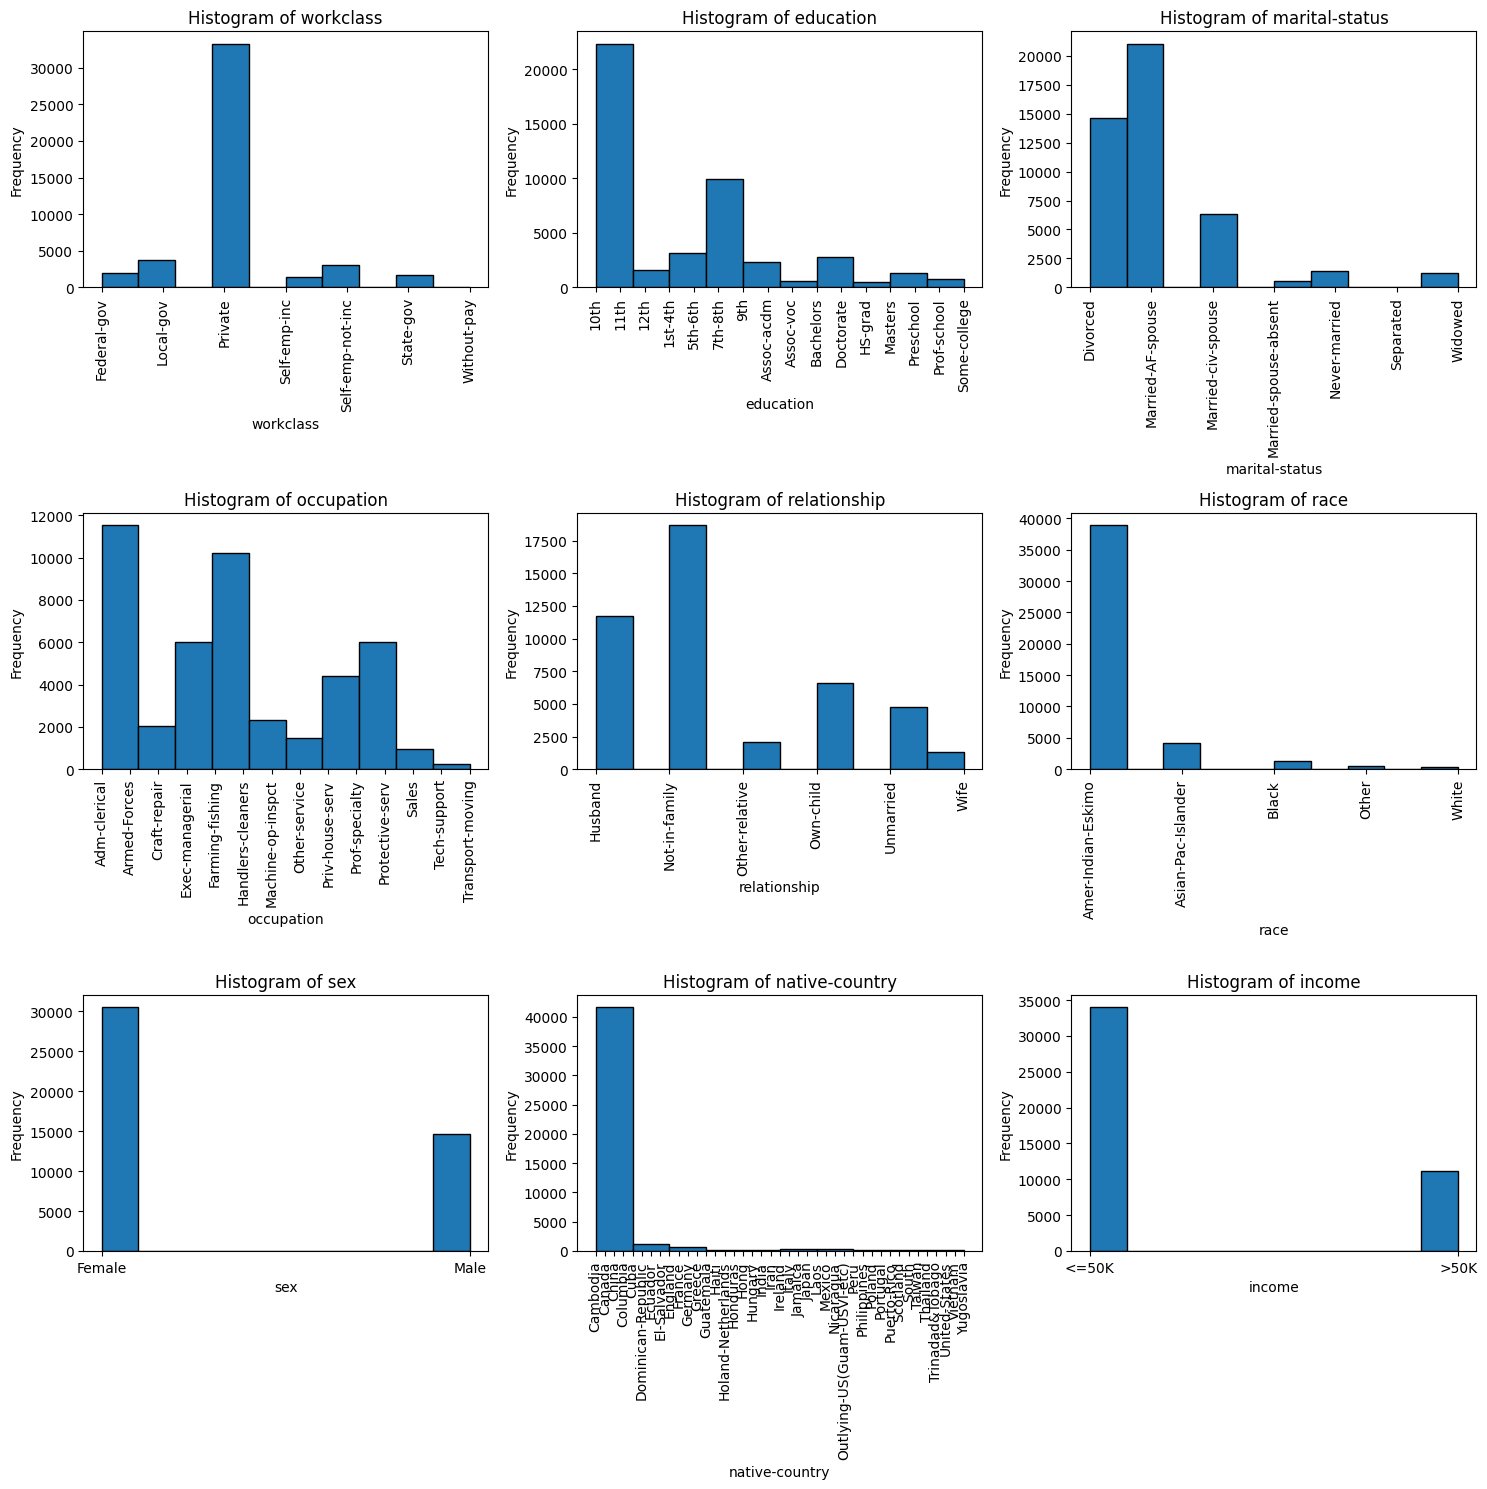

In [ ]:
plot_histograms(adult_dataset, categorical_cols, nrows=3,ncols=3)

In [ ]:
salary_group_counts = adult_dataset['income'].value_counts()
ratio_salary_dist = salary_group_counts[0]/salary_group_counts[1]
print(ratio_salary_dist.item())

3.034796573875803


<b>Interpretation:</b>
This dataset may be highly skewed to the salary category group of >50K.

###Visulize the salary distribution based on various protected groups

race


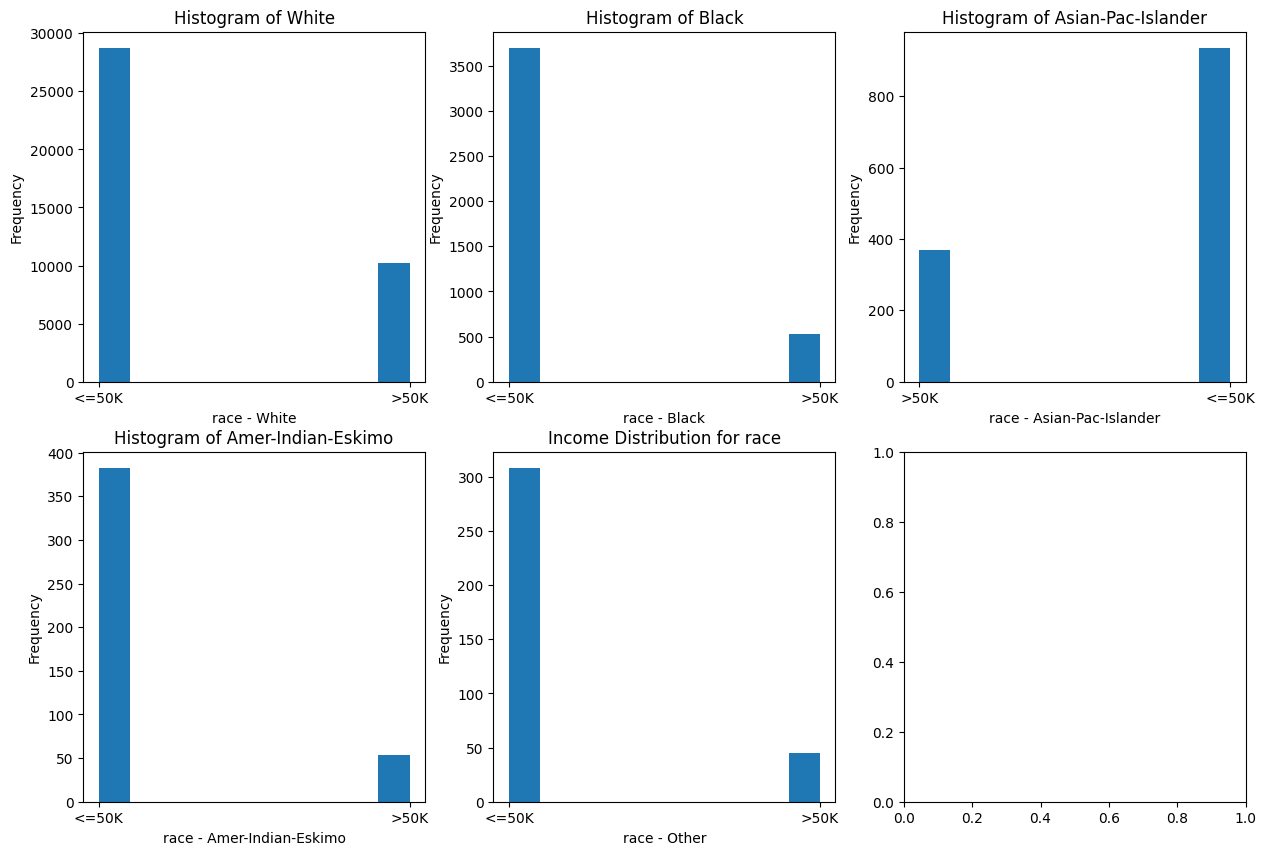

sex


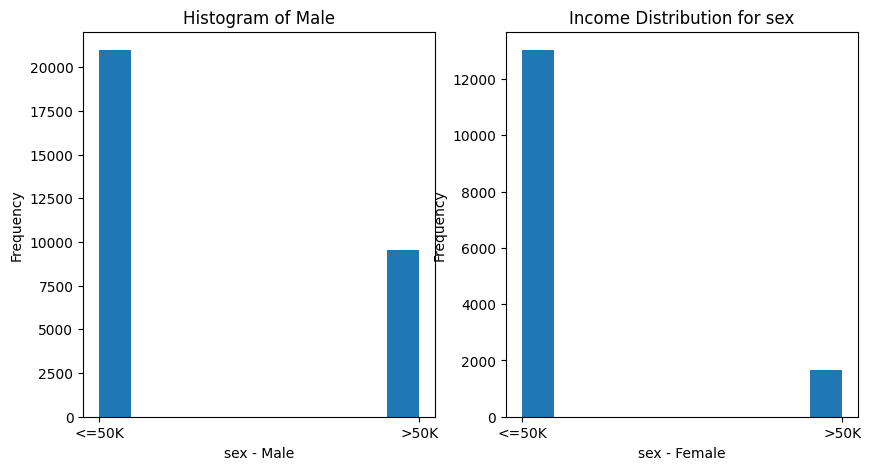

In [ ]:
for cur_cat in ['race', 'sex']:
  print(cur_cat)
  uniq_cat_item_list = adult_dataset[cur_cat].unique()
  uniq_cat_item_list = uniq_cat_item_list.tolist()

  nrows = int(len(uniq_cat_item_list) / 3) +1
  ncols = 3 if len(uniq_cat_item_list) > 3 else len(uniq_cat_item_list)
  # Flatten the axes array for easier iteration


  fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))  # Adjust figsize as needed
  axes = axes.flatten()


  for i, cur_cat_item in enumerate(uniq_cat_item_list):
    ax = axes[i]
    cur_cat_income = adult_dataset[adult_dataset[cur_cat] == cur_cat_item]['income']
    ax.hist(cur_cat_income)
    ax.set_xlabel(f'{cur_cat} - {cur_cat_item}')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Histogram of {cur_cat_item}')
    plt.sca(ax)

  plt.title(f'Income Distribution for {cur_cat}') # Added title for clarity
  plt.show() # Added plt.show() to display each histogram separately


##Data Preprocessing

In [ ]:
def onehot_encode(df, column_name):
  # Create the encoder
  encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
  # Fit the encoder to the 'occupation' column
  encoder.fit(df[[column_name]])
  # Transform the 'occupation' column
  encoded_data = encoder.transform(df[[column_name]])
  # Create a DataFrame from the encoded data
  encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out([column_name]))
  # Concatenate the encoded DataFrame with the original DataFrame
  #print("encoded column : " , column)
  #print(encoded_df.head())
  df = pd.concat([df, encoded_df], axis=1)
  # Drop the original 'occupation' column
  df = df.drop(column_name, axis=1)
  return df

In [ ]:
adult_dataset['income'].replace({'<=50K': 0, '>50K': 1}, inplace = True)
adult_dataset['Age_Group'] = adult_dataset['age'].apply(lambda x: 1 if 26 <= x <= 47 else 0)
adult_dataset['sex'].replace({'Female': 0, 'Male': 1}, inplace=True)
adult_dataset["Gender_Label"] = adult_dataset["sex"].replace({1: 1, 0: 0})  # female 0, male 1
adult_dataset['race'].replace({'White': 1, 'Black': 0, 'Amer-Indian-Eskimo': 2, 'Asian-Pac-Islander': 2,  'Other': 2 }, inplace = True)
adult_dataset['Race_Group'] = adult_dataset['race'].apply(lambda x: 1 if x == 1 else 0)
adult_dataset['workclass'].replace({'Private': 0, 'Federal-gov': 2, 'Local-gov': 2,  'Self-emp-inc': 3, 'Self-emp-not-inc': 3, 'State-gov': 2, 'Without-pay': 4}, inplace = True)
adult_dataset['education'].replace({'10th': 1, '11th': 1, '12th': 1, '1st-4th': 0, '5th-6th': 0, '7th-8th': 0, '9th': 0, 'Assoc-acdm': 4, 'Assoc-voc': 4, 'Bachelors': 3, 'Doctorate': 4, 'HS-grad': 3, 'Masters': 4, 'Preschool': 0, 'Prof-school': 0, 'Some-college': 3}, inplace = True)
adult_dataset['marital-status'].replace({'Married-AF-spouse': 0, 'Married-civ-spouse': 0, 'Divorced': 1,  'Married-spouse-absent': 1, 'Never-married': 1, 'Separated': 1, 'Widowed': 1}, inplace = True)
#Gov Job, Individual , Salaried Pvt, Business
adult_dataset['occupation'].replace({'Adm-clerical': 1, 'Armed-Forces': 1, 'Craft-repair': 0, 'Exec-managerial': 3, 'Farming-fishing': 4, 'Handlers-cleaners': 0, 'Machine-op-inspct': 0, 'Other-service': 0, 'Priv-house-serv': 0, 'Prof-specialty': 3, 'Protective-serv': 4, 'Sales': 4, 'Tech-support': 3, 'Transport-moving': 4}, inplace = True)

#Relationship
adult_dataset['relationship'].replace({'Husband': 0, 'Not-in-family': 1, 'Other-relative': 2, 'Own-child': 3, 'Unmarried': 4, 'Wife': 5}, inplace = True)


In [ ]:
df = onehot_encode(adult_dataset, 'occupation')
df = onehot_encode(df, 'relationship')
df = onehot_encode(df, 'marital-status')
df = onehot_encode(df, 'race')
df = onehot_encode(df, 'workclass')
df = onehot_encode(df, 'education')
df = onehot_encode(df, 'native-country')

In [ ]:
df.dropna(inplace = True)
adult_dataset_processed = df
adult_dataset_processed.head()

,age,fnlwgt,education-num,sex,capital-gain,capital-loss,hours-per-week,income,Age_Group,Gender_Label,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,native-country_nan
0,39.0,77516.0,13.0,1.0,2174.0,0.0,40.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,50.0,83311.0,13.0,1.0,0.0,0.0,13.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,38.0,215646.0,9.0,1.0,0.0,0.0,40.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,53.0,234721.0,7.0,1.0,0.0,0.0,40.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,28.0,338409.0,13.0,0.0,0.0,0.0,40.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
#Change the scaling of continuous variable.
scaler = MinMaxScaler()
cont_variables = ['age', 'fnlwgt', 'education-num', 'hours-per-week']
adult_dataset_processed[cont_variables] = scaler.fit_transform(adult_dataset_processed[cont_variables])


## Model Training and Evaluation

Predictor variable : income

In [ ]:
#Split the dataset in training and testing.
features = adult_dataset_processed.drop('income', axis=1)
target = adult_dataset_processed['income']

(X_train, X_test, y_train, y_test) = train_test_split(features, target, test_size=0.2, random_state=42)

In [ ]:
def train_model(lgb_params, X_train, y_train, X_test, y_test):
  lgb_base_model = LGBMClassifier(random_seed=531, max_depth=6, num_leaves=33, **lgb_params)
  lgb_base_model.fit(X_train, y_train)
  y_pred_train = lgb_base_model.predict(X_train)
  y_pred_prob_train = lgb_base_model.predict_proba(X_train)[:, 1]
  accuracy = accuracy_score(y_train, y_pred_train)

  # evaluate model
  y_pred_test = lgb_base_model.predict(X_test)
  y_pred_prob_test = lgb_base_model.predict_proba(X_test)[:, 1]

  # performance metrics
  accuracy = accuracy_score(y_test, y_pred_test)
  precision = precision_score(y_test, y_pred_test)
  recall = recall_score(y_test, y_pred_test)
  f1 = f1_score(y_test, y_pred_test)
  roc_auc = roc_auc_score(y_test, y_pred_prob_test)

  print(f"Accuracy (Test): {accuracy:.4f}")
  print(f"Precision (Test): {precision:.4f}")
  print(f"Recall (Test): {recall:.4f}")
  print(f"F1-Score (Test): {f1:.4f}")
  print(f"ROC-AUC (Test): {roc_auc:.4f}")

  result ={}
  result['accuracy'] = accuracy
  result['precision'] = precision
  result['recall'] = recall
  result['f1'] = f1
  result['roc_auc'] = roc_auc

  # there was a biggest decrease in the ROC curve, so it is worthwhile to visualize it
  fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_test)
  plt.figure(figsize=(8, 6))
  plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
  plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
  plt.title("ROC Curve")
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.legend()
  plt.grid(True)
  plt.show()
  return y_pred_test, y_pred_prob_test, result


In [ ]:
def report_fairness( y_train, y_test, y_pred_test, y_pred_prob_test,  protected_attribute_names, privileged_groups, unprivileged_groups):
  # combine X_train and y_train for BinaryLabelDataset
  train_ds = BinaryLabelDataset(
    df=X_train.join(y_train),
    label_names=["income"],
    protected_attribute_names = protected_attribute_names,
    favorable_label=0,  # 0 did not default
    unfavorable_label=1  # 1 defaulted
  )
  # then, compute our metrics for training data
  metrics_train_ds = BinaryLabelDatasetMetric(
      train_ds,
      unprivileged_groups=unprivileged_groups,
      privileged_groups=privileged_groups
  )

  # print results from training data
  print("Training Data Metrics:")
  print(f"Statistical Parity Difference (SPD): {metrics_train_ds.statistical_parity_difference():.4f}")
  print(f"Disparate Impact (DI): {metrics_train_ds.disparate_impact():.4f}")
  print(f"Smoothed Empirical Differential Fairness (SEDF): {metrics_train_ds.smoothed_empirical_differential_fairness():.4f}")

  test_ds = BinaryLabelDataset(
    df=X_test.join(y_test),
    label_names=["income"],
    #protected_attribute_names=["Age_Group", "Gender_Label"],
    protected_attribute_names = protected_attribute_names,
    favorable_label=0,  # 0 no default
    unfavorable_label=1  # 1 defaulted
  )

  # add predictions and scores to the test dataset for our fairness metrics
  test_pred_ds = test_ds.copy(deepcopy=True)
  test_pred_ds.labels = y_pred_test.reshape(-1, 1)
  test_pred_ds.scores = y_pred_prob_test.reshape(-1, 1)

  # Compute fairness metrics
  metrics_test_cls = ClassificationMetric(
      test_ds,
      test_pred_ds,
      unprivileged_groups=unprivileged_groups,
      privileged_groups=privileged_groups
  )

  # print fairness metrics
  print("\nFairness Metrics on Test Data:")
  print(f"Statistical Parity Difference (SPD): {metrics_test_cls.statistical_parity_difference():.4f}")
  print(f"Disparate Impact (DI): {metrics_test_cls.disparate_impact():.4f}")
  print(f"Smoothed Empirical Differential Fairness (SEDF): {metrics_train_ds.smoothed_empirical_differential_fairness():.4f}")
  return train_ds, test_ds,metrics_train_ds, metrics_test_cls

Accuracy (Test): 0.8306
Precision (Test): 0.6401
Recall (Test): 0.6748
F1-Score (Test): 0.6570
ROC-AUC (Test): 0.8847


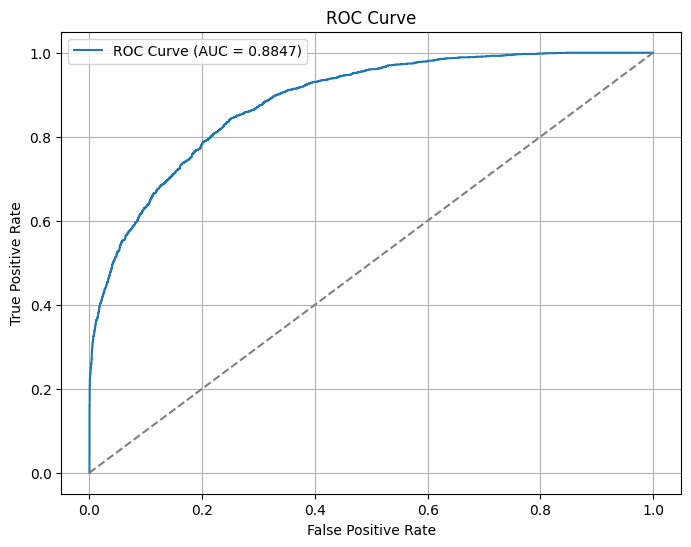

In [ ]:
# train our LightGBM classifier
lgb_params = {
    'learning_rate': 0.4,
    'reg_alpha': 21,
    'reg_lambda': 1,
    'scale_pos_weight': 1.8,
    'verbosity' : -1
}

y_pred_test, y_pred_prob_test, result = train_model(lgb_params, X_train, y_train, X_test, y_test)

In [ ]:
protected_attribute_names=["Age_Group"]
privileged_groups = [{"Age_Group": 1}]
unprivileged_groups = [{"Age_Group": 0  }]
print("Understand bias with - Age  in the dataset")
train_ds, test_ds,metrics_train_ds, metrics_test_cls = report_fairness( y_train, y_test, y_pred_test, y_pred_prob_test,  protected_attribute_names, privileged_groups, unprivileged_groups)



Understand bias with - Age  in the dataset
Training Data Metrics:
Statistical Parity Difference (SPD): 0.0697
Disparate Impact (DI): 1.0967
Smoothed Empirical Differential Fairness (SEDF): 0.2868

Fairness Metrics on Test Data:
Statistical Parity Difference (SPD): 0.0498
Disparate Impact (DI): 1.0687
Smoothed Empirical Differential Fairness (SEDF): 0.2868


Statistical Parity Difference (SPD) = 0.0697 suggests that there is a 6.97% difference in the positive prediction rates between the privileged and unprivileged groups. This indicates a potential disparity in treatment.

Disparate Impact (DI): 1.0967 signifies that underprivileged group is about 9.67% more likely to received a favourable outcome compared to the privileged group.


When Race, Gender and Age attributes included in the feature variables as a protected attributed. The result is very signficant.

Statistical Parity Difference (SPD): 0.2330
Disparate Impact (DI): 1.3568
Smoothed Empirical Differential Fairness (SEDF): 1.9347

Interpretation:

SPD = 0.0412 suggests that there is a 4.12% difference in the positive prediction rates between the privileged and unprivileged groups.This indicates a potential disparity in treatment, where the privileged group is slightly more likely to receive a favorable outcome.

DI = 1.0565 signifies that the unprivileged group is about 5.65% more likely to receive a favorable outcome compared to the privileged group. This could be due to the mitigation strategies applied to address the initial bias observed in training data.

SEDF =1.5085 indicates a level of disparity in the model's predictions. There are larger probability differences between individuals based on their group membership. This suggests that while SPD and DI show a reduced disparity, the model may not be fully ensuring individual fairness, especially in certain areas of the feature space. This may need further investigation and potential adjustments in your fairness mitigation strategy.

## Quantifying Model Bias

Accuracy (Test): 0.8306
Precision (Test): 0.6401
Recall (Test): 0.6748
F1-Score (Test): 0.6570
ROC-AUC (Test): 0.8847


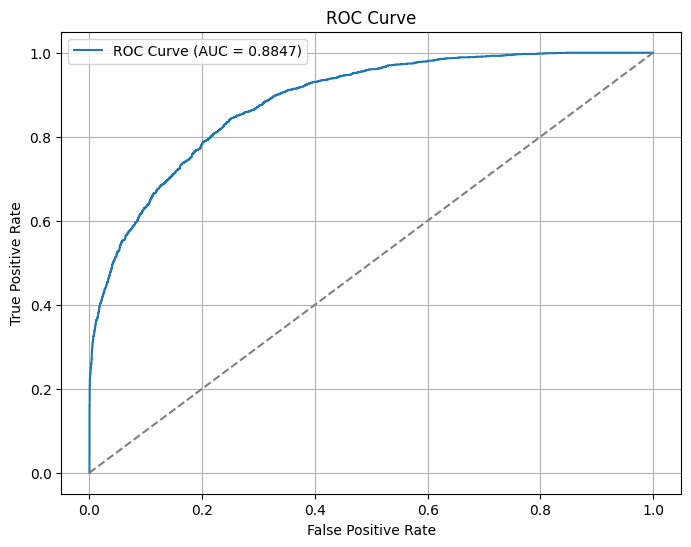

In [ ]:
# train our LightGBM classifier
lgb_params = {
    'learning_rate': 0.4,
    'reg_alpha': 21,
    'reg_lambda': 1,
    'scale_pos_weight': 1.8,
    'verbosity' : -1
}

y_pred_test, y_pred_prob_test, result = train_model(lgb_params, X_train, y_train, X_test, y_test)


In [ ]:
protected_attribute_names=["Age_Group", "Gender_Label"]
privileged_groups = [{"Age_Group": 1, "Gender_Label":1}]
unprivileged_groups = [{"Age_Group": 0 ,"Gender_Label":0, },{"Age_Group": 0, "Gender_Label": 1}, {"Age_Group": 1, "Gender_Label": 0}]
print("Understand bias with - Age and Gender in the dataset")
train_ds, test_ds,metrics_train_ds, metrics_test_cls = report_fairness(y_train, y_test, y_pred_test, y_pred_prob_test,  protected_attribute_names, privileged_groups, unprivileged_groups)




Understand bias with - Age and Gender in the dataset
Training Data Metrics:
Statistical Parity Difference (SPD): 0.1414
Disparate Impact (DI): 1.2125
Smoothed Empirical Differential Fairness (SEDF): 1.5085

Fairness Metrics on Test Data:
Statistical Parity Difference (SPD): 0.1730
Disparate Impact (DI): 1.2693
Smoothed Empirical Differential Fairness (SEDF): 1.5085


In [ ]:
protected_attribute_names=["Age_Group", "Gender_Label","Race_Group"]
privileged_groups = [{"Age_Group": 1, "Gender_Label":1, "Race_Group":1}]
unprivileged_groups = [{"Age_Group": 0 ,"Gender_Label":0, "Race_Group":0},{"Age_Group": 0, "Gender_Label": 1, "Race_Group":0}, {"Age_Group": 1, "Gender_Label": 0,"Race_Group":0}]
print("Understand bias with - Age, Gender and Race in the dataset")
train_ds, test_ds,metrics_train_ds, metrics_test_cls = report_fairness( y_train, y_test, y_pred_test, y_pred_prob_test,  protected_attribute_names, privileged_groups, unprivileged_groups)


Understand bias with - Age, Gender and Race in the dataset
Training Data Metrics:
Statistical Parity Difference (SPD): 0.2330
Disparate Impact (DI): 1.3568
Smoothed Empirical Differential Fairness (SEDF): 1.9347

Fairness Metrics on Test Data:
Statistical Parity Difference (SPD): 0.2967
Disparate Impact (DI): 1.4757
Smoothed Empirical Differential Fairness (SEDF): 1.9347


## Mitigating Bias

### Pre-Processing Bias Mitigation Methods

#### Reweighting (Reweighing) Method

In [ ]:
# apply reweighing
reweighter = Reweighing(
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)
reweighter.fit(train_ds)
train_rw_ds = reweighter.transform(train_ds)

# metrics for the reweighted training dataset
metrics_train_rw_ds = BinaryLabelDatasetMetric(
    train_rw_ds,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

# print metrics
print('Reweighted Training Data Metrics:')
print(f'Statistical Parity Difference (SPD): {metrics_train_rw_ds.statistical_parity_difference():.4f}')
print(f'Disparate Impact (DI): {metrics_train_rw_ds.disparate_impact():.4f}')
print(f'Smoothed Empirical Differential Fairness (SEDF): {metrics_train_rw_ds.smoothed_empirical_differential_fairness():.4f}')


Reweighted Training Data Metrics:
Statistical Parity Difference (SPD): 0.0000
Disparate Impact (DI): 1.0000
Smoothed Empirical Differential Fairness (SEDF): 1.5575


### Training LightGBM on the Reweighted Dataset

In [ ]:
# train LightGbM
lgb_rw_model = LGBMClassifier(
    random_state=531,
    max_depth=6,
    num_leaves=33,
    **lgb_params
)

# use reweighted dataset's instance weights
lgb_rw_model.fit(
    X_train,
    y_train,
    sample_weight=train_rw_ds.instance_weights
)

LGBMClassifier(learning_rate=0.4, max_depth=6, num_leaves=33, random_state=531,
               reg_alpha=21, reg_lambda=1, scale_pos_weight=1.8, verbosity=-1)

In [ ]:
# evaluate performance metrics
y_pred_test_rw = lgb_rw_model.predict(X_test)
y_pred_prob_test_rw = lgb_rw_model.predict_proba(X_test)[:, 1]

# Compute performance metrics
accuracy_rw = accuracy_score(y_test, y_pred_test_rw)
precision_rw = precision_score(y_test, y_pred_test_rw)
recall_rw = recall_score(y_test, y_pred_test_rw)
f1_rw = f1_score(y_test, y_pred_test_rw)
roc_auc_rw = roc_auc_score(y_test, y_pred_prob_test_rw)

# display
print("\nPerformance Metrics for Reweighted Model:")
print(f"Accuracy (Test): {accuracy_rw:.4f}")
print(f"Precision (Test): {precision_rw:.4f}")
print(f"Recall (Test): {recall_rw:.4f}")
print(f"F1-Score (Test): {f1_rw:.4f}")
print(f"ROC-AUC (Test): {roc_auc_rw:.4f}")


Performance Metrics for Reweighted Model:
Accuracy (Test): 0.8329
Precision (Test): 0.6643
Recall (Test): 0.6162
F1-Score (Test): 0.6394
ROC-AUC (Test): 0.8772


In [ ]:
# compute fairness metrics & add predictions/scores to test ds
test_pred_rw_ds = test_ds.copy(deepcopy=True)
test_pred_rw_ds.labels = y_pred_test_rw.reshape(-1, 1)
test_pred_rw_ds.scores = y_pred_prob_test_rw.reshape(-1, 1)

# fairness metrics for the reweighted model
metrics_test_rw_cls = ClassificationMetric(
    test_ds,
    test_pred_rw_ds,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

# print
print("\nFairness Metrics for Reweighted Model on Test Data:")
print(f"Statistical Parity Difference (SPD): {metrics_test_rw_cls.statistical_parity_difference():.4f}")
print(f"Disparate Impact (DI): {metrics_test_rw_cls.disparate_impact():.4f}")
print(f"Equal Opportunity Difference (EOD): {metrics_test_rw_cls.equal_opportunity_difference():.4f}")
print(f"Average Odds Difference (AOD): {metrics_test_rw_cls.average_odds_difference():.4f}")
print(f"Differential Fairness Bias Amplification (DFBA): {metrics_test_rw_cls.differential_fairness_bias_amplification():.4f}")


Fairness Metrics for Reweighted Model on Test Data:
Statistical Parity Difference (SPD): 0.1030
Disparate Impact (DI): 1.1406
Equal Opportunity Difference (EOD): 0.0109
Average Odds Difference (AOD): -0.0831
Differential Fairness Bias Amplification (DFBA): -0.1670


In [ ]:
# comparing results
print("\nComparison of Original and Reweighted Models:")
print("\nPerformance Metrics:")
print(f"Original Model Accuracy: {result['accuracy']:.4f} | Reweighted Model Accuracy: {accuracy_rw:.4f}")
print(f"Original Model Precision: {result['precision']:.4f} | Reweighted Model Precision: {precision_rw:.4f}")
print(f"Original Model Recall: {result['recall']:.4f} | Reweighted Model Recall: {recall_rw:.4f}")
print(f"Original Model F1-Score: {result['f1']:.4f} | Reweighted Model F1-Score: {f1_rw:.4f}")
print(f"Original Model ROC-AUC: {result['roc_auc']:.4f} | Reweighted Model ROC-AUC: {roc_auc_rw:.4f}")

print("\nFairness Metrics:")
print(f"Original SPD: {metrics_test_cls.statistical_parity_difference():.4f} | Reweighted SPD: {metrics_test_rw_cls.statistical_parity_difference():.4f}")
print(f"Original DI: {metrics_test_cls.disparate_impact():.4f} | Reweighted DI: {metrics_test_rw_cls.disparate_impact():.4f}")
print(f"Original SEDF: {metrics_test_cls.smoothed_empirical_differential_fairness():.4f} | Reweighted SEDF: {metrics_train_rw_ds.smoothed_empirical_differential_fairness():.4f}")


Comparison of Original and Reweighted Models:

Performance Metrics:
Original Model Accuracy: 0.8306 | Reweighted Model Accuracy: 0.8329
Original Model Precision: 0.6401 | Reweighted Model Precision: 0.6643
Original Model Recall: 0.6748 | Reweighted Model Recall: 0.6162
Original Model F1-Score: 0.6570 | Reweighted Model F1-Score: 0.6394
Original Model ROC-AUC: 0.8847 | Reweighted Model ROC-AUC: 0.8772

Fairness Metrics:
Original SPD: 0.2967 | Reweighted SPD: 0.1030
Original DI: 1.4757 | Reweighted DI: 1.1406
Original SEDF: 2.0482 | Reweighted SEDF: 1.5575


## Disparate Impact Remover (DIR)

In [ ]:
# define the levels for repair
levels = np.hstack([np.linspace(0., 1, 20), np.linspace(0.2, 1, 5)])
protected_index = train_ds.feature_names.index("Age_Group")

# initialize variables to track the best repair level
di = np.array([])  # Collect Disparate Impact for all levels
train_dir_ds = None
test_dir_ds = None
X_train_dir = None
X_test_dir = None
lgb_dir_model = None

In [ ]:
# set seed
rand = 531
np.random.seed(rand)

# loop through repair levels
for level in tqdm(levels):
    #apply DIR at the current repair level
    di_remover = DisparateImpactRemover(repair_level=level)
    train_dir_ds_i = di_remover.fit_transform(train_ds)
    test_dir_ds_i = di_remover.fit_transform(test_ds)

    #remove protected attribute from the features
    X_train_dir_i = np.delete(train_dir_ds_i.features, protected_index, axis=1)
    X_test_dir_i = np.delete(test_dir_ds_i.features, protected_index, axis=1)

    # train LightGBM model on the repaired dataset
    lgb_dir_model_i = lgb.LGBMClassifier(
        random_state=rand, max_depth=5, num_leaves=33, verbose=-1, **lgb_params
    )
    lgb_dir_model_i.fit(X_train_dir_i, train_dir_ds_i.labels)

    #predict on the repaired test dataset
    test_dir_ds_pred_i = test_dir_ds_i.copy()
    test_dir_ds_pred_i.labels = lgb_dir_model_i.predict(X_test_dir_i)

    # fairness metrics
    metrics_test_dir_ds = BinaryLabelDatasetMetric(
        test_dir_ds_pred_i,
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups,
    )
    di_i = metrics_test_dir_ds.disparate_impact()

    # track and print DI for this level
    print(f"Repair Level: {level:.2f}, Disparate Impact: {di_i:.4f}")

    # update the best results if this level is closest to DI=1
    if (di.shape[0] == 0) or (np.min(np.abs(di - 1)) >= abs(di_i - 1)):
        train_dir_ds = train_dir_ds_i
        test_dir_ds = test_dir_ds_i
        X_train_dir = X_train_dir_i
        X_test_dir = X_test_dir_i
        lgb_dir_model = lgb_dir_model_i

    # append to DI list
    di = np.append(di, di_i)


  4%|▍         | 1/25 [00:20<08:21, 20.89s/it]

Repair Level: 0.00, Disparate Impact: 1.4691


  8%|▊         | 2/25 [00:37<07:00, 18.28s/it]

Repair Level: 0.05, Disparate Impact: 1.4655


 12%|█▏        | 3/25 [00:53<06:25, 17.53s/it]

Repair Level: 0.11, Disparate Impact: 1.4734


 16%|█▌        | 4/25 [01:11<06:07, 17.48s/it]

Repair Level: 0.16, Disparate Impact: 1.4793


 20%|██        | 5/25 [01:30<06:03, 18.16s/it]

Repair Level: 0.21, Disparate Impact: 1.4990


 24%|██▍       | 6/25 [01:48<05:42, 18.02s/it]

Repair Level: 0.26, Disparate Impact: 1.5782


 28%|██▊       | 7/25 [02:05<05:16, 17.61s/it]

Repair Level: 0.32, Disparate Impact: 1.6041


 32%|███▏      | 8/25 [02:22<04:55, 17.36s/it]

Repair Level: 0.37, Disparate Impact: 1.5983


 36%|███▌      | 9/25 [02:39<04:38, 17.42s/it]

Repair Level: 0.42, Disparate Impact: 1.6041


 40%|████      | 10/25 [02:56<04:18, 17.21s/it]

Repair Level: 0.47, Disparate Impact: 1.6199


 44%|████▍     | 11/25 [03:13<04:00, 17.18s/it]

Repair Level: 0.53, Disparate Impact: 1.5057


 48%|████▊     | 12/25 [03:30<03:41, 17.01s/it]

Repair Level: 0.58, Disparate Impact: 1.5281


 52%|█████▏    | 13/25 [03:46<03:21, 16.75s/it]

Repair Level: 0.63, Disparate Impact: 1.5152


 56%|█████▌    | 14/25 [04:02<03:01, 16.54s/it]

Repair Level: 0.68, Disparate Impact: 1.5138


 60%|██████    | 15/25 [04:19<02:45, 16.59s/it]

Repair Level: 0.74, Disparate Impact: 1.5345


 64%|██████▍   | 16/25 [04:34<02:26, 16.30s/it]

Repair Level: 0.79, Disparate Impact: 1.5359


 68%|██████▊   | 17/25 [04:57<02:26, 18.28s/it]

Repair Level: 0.84, Disparate Impact: 1.5686


 72%|███████▏  | 18/25 [05:12<02:01, 17.31s/it]

Repair Level: 0.89, Disparate Impact: 1.5161


 76%|███████▌  | 19/25 [05:27<01:39, 16.62s/it]

Repair Level: 0.95, Disparate Impact: 1.5273


 80%|████████  | 20/25 [05:42<01:20, 16.08s/it]

Repair Level: 1.00, Disparate Impact: 1.5558


 84%|████████▍ | 21/25 [06:00<01:06, 16.64s/it]

Repair Level: 0.20, Disparate Impact: 1.5029


 88%|████████▊ | 22/25 [06:17<00:50, 16.70s/it]

Repair Level: 0.40, Disparate Impact: 1.6113


 92%|█████████▏| 23/25 [06:34<00:33, 16.74s/it]

Repair Level: 0.60, Disparate Impact: 1.5288


 96%|█████████▌| 24/25 [06:50<00:16, 16.60s/it]

Repair Level: 0.80, Disparate Impact: 1.5294


100%|██████████| 25/25 [07:05<00:00, 17.03s/it]

Repair Level: 1.00, Disparate Impact: 1.5558


In [ ]:
# print the best repair level and its corresponding disparate impact
best_level = levels[np.argmin(np.abs(di - 1))]
print(f"Best Repair Level: {best_level:.2f}")
print(f"Disparate Impact at Best Level: {di[np.argmin(np.abs(di - 1))]:.4f}")


Best Repair Level: 0.05
Disparate Impact at Best Level: 1.4655


In [ ]:
# predict on the modified test data (from DIR)
y_pred_test_dir = lgb_dir_model.predict(X_test_dir)
y_pred_prob_test_dir = lgb_dir_model.predict_proba(X_test_dir)[:, 1]

# compute performance metrics on the test data
accuracy_test_dir = accuracy_score(y_test, y_pred_test_dir)
precision_test_dir = precision_score(y_test, y_pred_test_dir)
recall_test_dir = recall_score(y_test, y_pred_test_dir)
f1_test_dir = f1_score(y_test, y_pred_test_dir)
roc_auc_test_dir = roc_auc_score(y_test, y_pred_prob_test_dir)

#display
print("Performance Metrics on Test Data (DIR Applied):")
print(f"Accuracy: {accuracy_test_dir:.4f}")
print(f"Precision: {precision_test_dir:.4f}")
print(f"Recall: {recall_test_dir:.4f}")
print(f"F1-Score: {f1_test_dir:.4f}")
print(f"ROC-AUC: {roc_auc_test_dir:.4f}")

# predictions and scores to the BinaryLabelDataset for our fairness metrics
test_dir_ds_pred = test_dir_ds.copy(deepcopy=True)
test_dir_ds_pred.labels = y_pred_test_dir.reshape(-1, 1)
test_dir_ds_pred.scores = y_pred_prob_test_dir.reshape(-1, 1)

# fairness metrics
metrics_test_dir_cls = ClassificationMetric(
    test_dir_ds,
    test_dir_ds_pred,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

# display
print("\nFairness Metrics on Test Data (DIR Applied):")
print(f"Statistical Parity Difference (SPD): {metrics_test_dir_cls.statistical_parity_difference():.4f}")
print(f"Disparate Impact (DI): {metrics_test_dir_cls.disparate_impact():.4f}")
print(f"Equal Opportunity Difference (EOD): {metrics_test_dir_cls.equal_opportunity_difference():.4f}")
print(f"Average Odds Difference (AOD): {metrics_test_dir_cls.average_odds_difference():.4f}")
print(f"Differential Fairness Bias Amplification (DFBA): {metrics_test_dir_cls.differential_fairness_bias_amplification():.4f}")


Performance Metrics on Test Data (DIR Applied):
Accuracy: 0.8305
Precision: 0.6404
Recall: 0.6728
F1-Score: 0.6562
ROC-AUC: 0.8847

Fairness Metrics on Test Data (DIR Applied):
Statistical Parity Difference (SPD): 0.2919
Disparate Impact (DI): 1.4655
Equal Opportunity Difference (EOD): 0.1772
Average Odds Difference (AOD): 0.1552
Differential Fairness Bias Amplification (DFBA): 0.6266


In [ ]:
# Comparison of ALL Performance Metrics
print("\nComparison of Performance Metrics Across Models:")
print(f"{'Metric':<15}{'Original':<15}{'Reweighted':<15}{'DIR Applied':<15}")
print("-" * 60)
print(f"{'Accuracy':<15}{result['accuracy']:<15.4f}{accuracy_rw:<15.4f}{accuracy_test_dir:<15.4f}")
print(f"{'Precision':<15}{result['precision']:<15.4f}{precision_rw:<15.4f}{precision_test_dir:<15.4f}")
print(f"{'Recall':<15}{result['recall']:<15.4f}{recall_rw:<15.4f}{recall_test_dir:<15.4f}")
print(f"{'F1-Score':<15}{result['f1']:<15.4f}{f1_rw:<15.4f}{f1_test_dir:<15.4f}")
print(f"{'ROC-AUC':<15}{result['roc_auc']:<15.4f}{roc_auc_rw:<15.4f}{roc_auc_test_dir:<15.4f}")

# Comparison of ALL Fairness Metrics (SPD, DI, SEDF)
print("\nComparison of Fairness Metrics Across Models:")
print(f"{'Metric':<15}{'Original':<15}{'Reweighted':<15}{'DIR Applied':<15}")
print("-" * 60)
print(f"{'SPD':<15}{metrics_test_cls.statistical_parity_difference():<15.4f}{metrics_test_rw_cls.statistical_parity_difference():<15.4f}{metrics_test_dir_cls.statistical_parity_difference():<15.4f}")
print(f"{'DI':<15}{metrics_test_cls.disparate_impact():<15.4f}{metrics_test_rw_cls.disparate_impact():<15.4f}{metrics_test_dir_cls.disparate_impact():<15.4f}")
print(f"{'SEDF':<15}{metrics_test_cls.smoothed_empirical_differential_fairness():<15.4f}{metrics_train_rw_ds.smoothed_empirical_differential_fairness():<15.4f}{metrics_test_dir_cls.smoothed_empirical_differential_fairness():<15.4f}")


Comparison of Performance Metrics Across Models:
Metric         Original       Reweighted     DIR Applied    
------------------------------------------------------------
Accuracy       0.8306         0.8329         0.8305         
Precision      0.6401         0.6643         0.6404         
Recall         0.6748         0.6162         0.6728         
F1-Score       0.6570         0.6394         0.6562         
ROC-AUC        0.8847         0.8772         0.8847         

Comparison of Fairness Metrics Across Models:
Metric         Original       Reweighted     DIR Applied    
------------------------------------------------------------
SPD            0.2967         0.1030         0.2919         
DI             1.4757         1.1406         1.4655         
SEDF           2.0482         1.5575         2.0482         


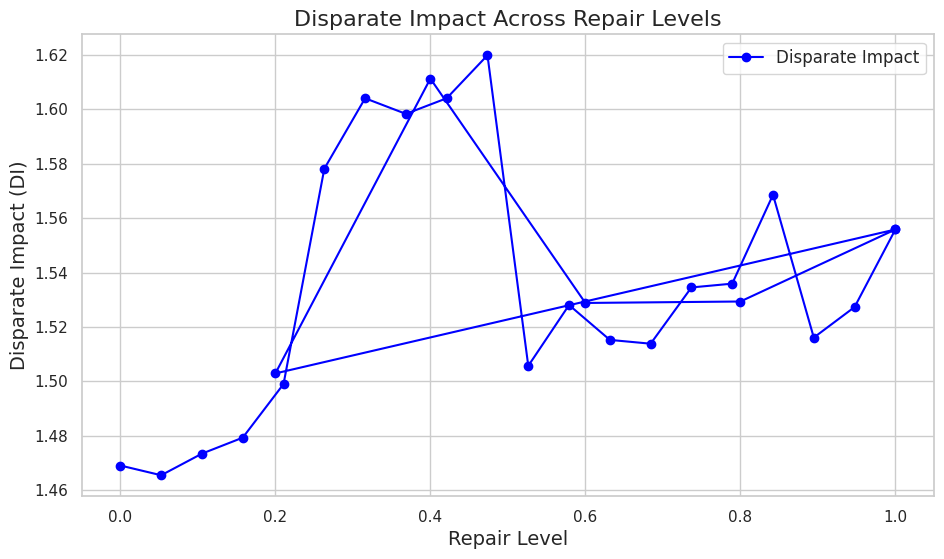

In [ ]:
# Plot Disparate Impact across repair levels
import matplotlib.pyplot as plt
import seaborn as sns

di = di[:len(levels)]

# Use Seaborn style for better visuals
sns.set(style="whitegrid")

plt.figure(figsize=(11, 6))

# Plot the Disparate Impact (DI) against repair levels
plt.plot(levels, di, marker="o", linestyle="-", color="blue", label="Disparate Impact")

# Add labels, title, and legend
plt.ylabel("Disparate Impact (DI)", fontsize=14)
plt.xlabel("Repair Level", fontsize=14)
plt.title("Disparate Impact Across Repair Levels", fontsize=16)
plt.legend(fontsize=12)

# Show grid for readability
plt.grid(True)

# Display the plot
plt.show()

from IPython.display import display
display(plt.gcf())

## Apply the Laplace Mechanism to Add Noise to Ethnicity Counts

In [ ]:
adult_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45222 entries, 0 to 48841
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             45222 non-null  int64 
 1   workclass       45222 non-null  int64 
 2   fnlwgt          45222 non-null  int64 
 3   education       45222 non-null  int64 
 4   education-num   45222 non-null  int64 
 5   marital-status  45222 non-null  int64 
 6   occupation      45222 non-null  int64 
 7   relationship    45222 non-null  int64 
 8   race            45222 non-null  int64 
 9   sex             45222 non-null  int64 
 10  capital-gain    45222 non-null  int64 
 11  capital-loss    45222 non-null  int64 
 12  hours-per-week  45222 non-null  int64 
 13  native-country  45222 non-null  object
 14  income          45222 non-null  int64 
 15  Age_Group       45222 non-null  int64 
 16  Gender_Label    45222 non-null  int64 
 17  Race_Group      45222 non-null  int64 
dtypes: int64(17

In [ ]:
#Count ethinicity in the dataset.
ethnicity_counts = adult_dataset_org['race'].value_counts()

In [ ]:
print(ethnicity_counts)

race
White                 41762
Black                  4685
Asian-Pac-Islander     1519
Amer-Indian-Eskimo      470
Other                   406
Name: count, dtype: int64


In [ ]:
np.random.seed(531)

# Define Laplace mechanism function to add differential privacy noise to ethnicity counts
def apply_laplace_mechanism(counts, epsilon, sensitivity=1):
    noisy_counts = {}
    for key, value in counts.items():
        noise = np.random.laplace(loc=0, scale=sensitivity/epsilon)
        noisy_counts[key] = max(0, value + noise)  # Ensure counts don't go negative
    return noisy_counts

# set privacy budget to inject noise
epsilon_values = [0.1, 0.5, 1.0]

# Define a function to calculate percent relative error
def pct_error(orig, priv):
    if orig == 0:
        return 0  # To avoid division by zero if original count is zero
    return (priv - orig) / orig * 100.0

# Calculate and print change in representation for each ethnicity for each epsilon value

 # NOTE: To calculate the impact of representation on other variables (e.g., Income, Location),
        # you can switch out the 'ethnicity_counts' variable with counts for the desired category.
        # For example, replace 'ethnicity_counts' with 'income_counts_native_american' to focus on income levels.
for epsilon in epsilon_values:
    noisy_ethnicity_counts = apply_laplace_mechanism(ethnicity_counts.to_dict(), epsilon)

    print(f"\nChange in Representation with Epsilon = {epsilon}:")
    for ethnicity in ethnicity_counts.index:
        original_count = ethnicity_counts[ethnicity]
        noisy_count = noisy_ethnicity_counts[ethnicity]

        # Calculate change in representation
        if original_count > 0:
            change_in_representation = ((noisy_count - original_count) / original_count) * 100
        else:
            change_in_representation = 0  #  handle cases where original_count might be 0

        # Print
        print(f"Ethnicity: {ethnicity}")
        print(f" - Original Count: {original_count}")
        print(f" - Noisy Count: {noisy_count}")
        print(f" - Change in Representation (%): {change_in_representation:.2f}%\n")




Change in Representation with Epsilon = 0.1:
Ethnicity: White
 - Original Count: 41762
 - Noisy Count: 41766.77416512883
 - Change in Representation (%): 0.01%

Ethnicity: Black
 - Original Count: 4685
 - Noisy Count: 4681.5735692207645
 - Change in Representation (%): -0.07%

Ethnicity: Asian-Pac-Islander
 - Original Count: 1519
 - Noisy Count: 1542.0142737650235
 - Change in Representation (%): 1.52%

Ethnicity: Amer-Indian-Eskimo
 - Original Count: 470
 - Noisy Count: 473.36970634499875
 - Change in Representation (%): 0.72%

Ethnicity: Other
 - Original Count: 406
 - Noisy Count: 438.0061513542296
 - Change in Representation (%): 7.88%


Change in Representation with Epsilon = 0.5:
Ethnicity: White
 - Original Count: 41762
 - Noisy Count: 41760.08718802613
 - Change in Representation (%): -0.00%

Ethnicity: Black
 - Original Count: 4685
 - Noisy Count: 4685.247822371485
 - Change in Representation (%): 0.01%

Ethnicity: Asian-Pac-Islander
 - Original Count: 1519
 - Noisy Count: 15

##Generate Relative Error Visualisation

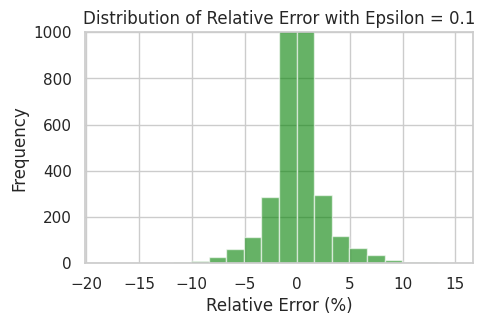

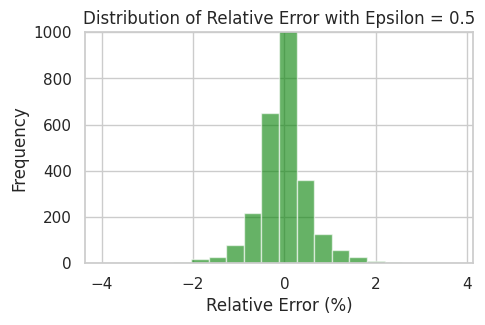

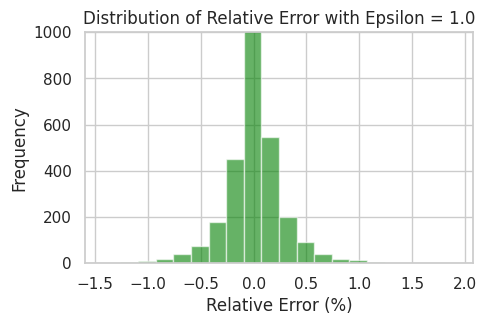

In [ ]:
# take a look at overall relative error
def graph_relative_error_histogram(original_counts, epsilon_values, num_samples=1000):
    for epsilon in epsilon_values:
        relative_errors = []

        # Generate differentially private answers and calculate relative errors
        for _ in range(num_samples):
            noisy_counts = apply_laplace_mechanism(original_counts.to_dict(), epsilon)
            for eth in original_counts.index:       # replace "eth" with "income_level" or desired variable
                original_count = original_counts[eth] # replace "eth" with "income_level" or desired variable
                noisy_count = noisy_counts[eth] # replace "eth" with "income_level" or desired variable

                # Calculate relative error
                relative_error = pct_error(original_count, noisy_count)
                relative_errors.append(relative_error)

        # Plot histogram of relative errors
        plt.figure(figsize=(5, 3))
        plt.hist(relative_errors, bins=20, alpha=0.6, color='green')
        plt.xlabel('Relative Error (%)')
        plt.ylabel('Frequency')
        plt.title(f'Distribution of Relative Error with Epsilon = {epsilon}')
        plt.grid(True)
        plt.ylim(0, 1000)
        #plt.tight_layout()
        plt.show()
        from IPython.display import display
        display(plt.gcf())

# Visualize the relative error for the ethnicity counts with different epsilon values
graph_relative_error_histogram(ethnicity_counts, epsilon_values)



In [ ]:
race_income_data = adult_dataset[adult_dataset_org['race'] == 'Black']['income'].value_counts()
for income_level, count in race_income_data.items():
    print(f"{income_level}: {count}")


0: 3694
1: 534


In [ ]:
epsilon_values =  [0.1, 0.5, 1.0]
for cur_epsilon in epsilon_values:
    noisy_income_counts_race = apply_laplace_mechanism(race_income_data.to_dict(), epsilon)

    print(f"\nChange in Representation with Epsilon = {cur_epsilon}:")
    for cur_income in race_income_data.index:
        original_count = race_income_data[cur_income]
        noisy_count = noisy_income_counts_race[cur_income]

        # Calculate change in representation
        if original_count > 0:
            change_in_representation = ((noisy_count - original_count) / original_count) * 100
        else:
            change_in_representation = 0  #  handle cases where original_count might be 0

        # Print
        print(f"Current Income: {cur_income}")
        print(f" - Original Count: {original_count}")
        print(f" - Noisy Count: {noisy_count}")
        print(f" - Change in Representation (%): {change_in_representation:.2f}%\n")


Change in Representation with Epsilon = 0.1:
Current Income: 0
 - Original Count: 3694
 - Noisy Count: 3694.8010856695555
 - Change in Representation (%): 0.02%

Current Income: 1
 - Original Count: 534
 - Noisy Count: 533.5204598497893
 - Change in Representation (%): -0.09%


Change in Representation with Epsilon = 0.5:
Current Income: 0
 - Original Count: 3694
 - Noisy Count: 3693.8308074720535
 - Change in Representation (%): -0.00%

Current Income: 1
 - Original Count: 534
 - Noisy Count: 534.6720932424777
 - Change in Representation (%): 0.13%


Change in Representation with Epsilon = 1.0:
Current Income: 0
 - Original Count: 3694
 - Noisy Count: 3695.2468514537945
 - Change in Representation (%): 0.03%

Current Income: 1
 - Original Count: 534
 - Noisy Count: 534.2063886628404
 - Change in Representation (%): 0.04%



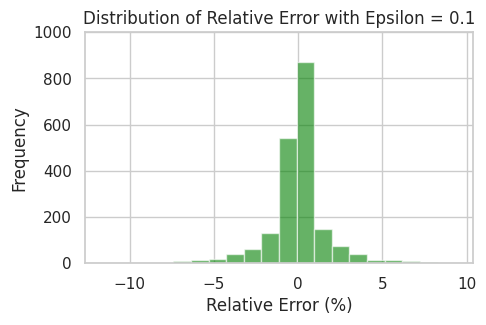

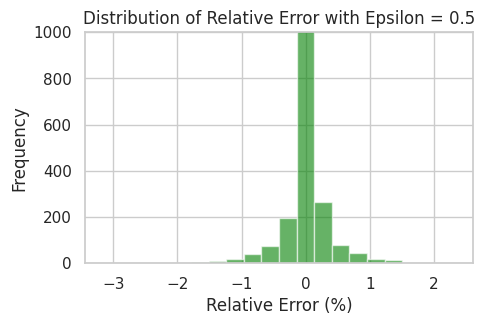

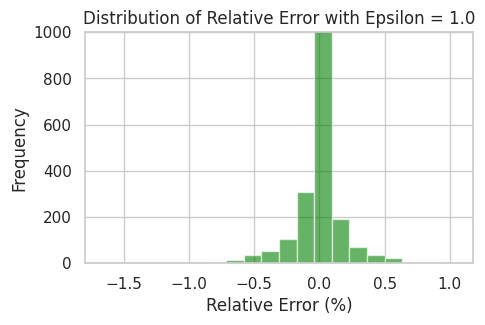

In [ ]:
graph_relative_error_histogram(race_income_data, epsilon_values)

In [ ]:
adult_dataset_laplace = adult_dataset.copy()

In [ ]:

# Function to apply Laplace mechanism
def apply_laplace_mechanism(counts, epsilon, sensitivity=1):
    noisy_counts = {}
    for key, value in counts.items():
        noise = np.random.laplace(loc=0, scale=sensitivity/epsilon)
        noisy_counts[key] = max(0, value + noise)
    return noisy_counts

# Get counts for race
ethnicity_counts = adult_dataset_laplace['race'].value_counts()

# Apply Laplace mechanism to race counts
epsilon_race = 0.5  # Adjust epsilon for race
noisy_ethnicity_counts = apply_laplace_mechanism(ethnicity_counts.to_dict(), epsilon_race)

# Get counts for income within each race (example with 'Black')
race_income_data = adult_dataset_laplace[adult_dataset_laplace['race'] == 'Black']['income'].value_counts()

# Apply Laplace mechanism to income counts for the chosen race
epsilon_income = 0.5  # Adjust epsilon for income
noisy_income_counts_race = apply_laplace_mechanism(race_income_data.to_dict(), epsilon_income)

print("Noisy Ethnicity Counts:")
print(noisy_ethnicity_counts.items())

# Update datasets with noisy counts
for ethnicity, noisy_count in noisy_ethnicity_counts.items():
    adult_dataset_laplace.loc[adult_dataset_laplace['race'] == ethnicity, 'race'] = noisy_count

for income_level, noisy_count in noisy_income_counts_race.items():
    adult_dataset_laplace.loc[(adult_dataset_laplace['race'] == 'Black') & (adult_dataset_laplace['income'] == income_level), 'income'] = noisy_count


Noisy Ethnicity Counts:
dict_items([(1, 38903.23977599126), (0, 4229.780773887326), (2, 2089.9840273261707)])


In [ ]:
# 1. Update 'adult_dataset_processed' with noisy ethnicity counts:
for ethnicity, noisy_count in noisy_ethnicity_counts.items():
    adult_dataset_laplace.loc[adult_dataset_laplace['race'] == ethnicity, 'race'] = noisy_count

# 2. Split into features and target:
features = adult_dataset_laplace.drop(['income','native-country'], axis=1)
target = adult_dataset_laplace['income']

#print(features.info())

# 3. Split into training and testing sets:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Before retraining, recalculate instance weights based on the new X_train, y_train
# Create a new BinaryLabelDataset with the updated X_train and y_train:
train_ds_laplace = BinaryLabelDataset(
    df=X_train.join(y_train),
    label_names=["income"],
    protected_attribute_names=["Age_Group", "Gender_Label","Race_Group"], # Update protected attributes if needed
    favorable_label=0,
    unfavorable_label=1
)

# Recalculate Reweighing
reweighter = Reweighing(
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)
reweighter.fit(train_ds_laplace)
train_rw_ds_laplace = reweighter.transform(train_ds_laplace)


# 4. Retrain the LightGBM model using the new instance weights:
lgb_rw_model = LGBMClassifier(
    random_state=531,
    max_depth=6,
    num_leaves=33,
    **lgb_params
)

lgb_rw_model.fit(
    X_train,
    y_train,
    sample_weight=train_rw_ds_laplace.instance_weights  # Use the new instance weights
)

LGBMClassifier(learning_rate=0.4, max_depth=6, num_leaves=33, random_state=531,
               reg_alpha=21, reg_lambda=1, scale_pos_weight=1.8, verbosity=-1)

##SHAP Explanation

In [ ]:
# Predict on the test set
y_pred = lgb_rw_model.predict(X_test)

In [ ]:
import shap
shap.initjs()


In [ ]:
# Explaining model predictions using SHAP
# Take a sample of the training data for SHAP

X_sample = shap.sample(X_train, 100)

# Create the SHAP explainer
explainer = shap.Explainer(lgb_rw_model.predict_proba, X_sample)

# Get SHAP values for the test set
shap_values = explainer(X_test)

PermutationExplainer explainer: 9046it [18:57,  7.92it/s]


In [ ]:
!pip install shap --quiet
import shap
import matplotlib.pyplot as plt
shap.initjs()


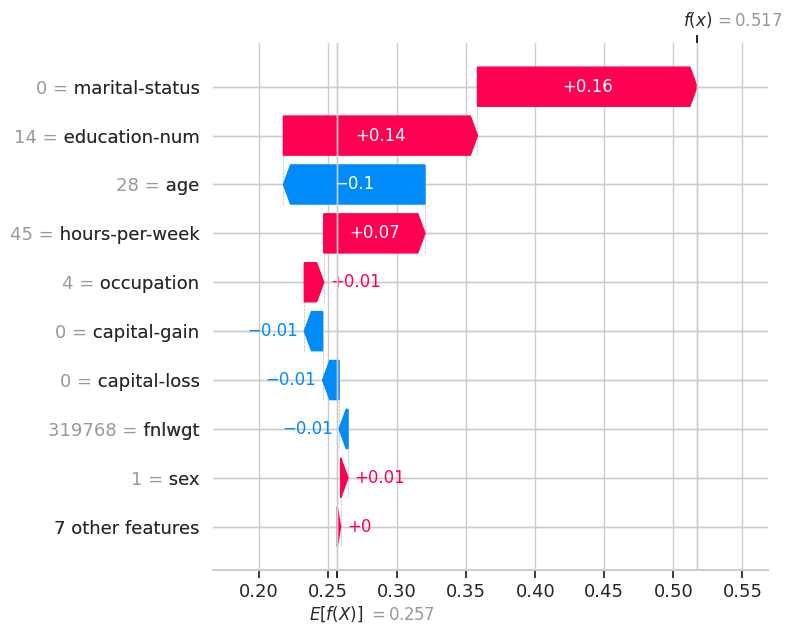

In [ ]:
# Javascript required for force plot
import shap
shap.initjs()
# Force plot
class_index = 1
data_index = 0
# shap.plots.force(shap_values[data_index,:,class_index])
import shap
import matplotlib.pyplot as plt
shap.initjs()
%matplotlib inline

# Clear previous plots
plt.clf()
plt.close('all')

# Only show one waterfall plot for class 1 (e.g., income >50K), data point 0
single_plot = shap.plots.waterfall(shap_values[0, :, 1], show=False)

# Force just one output
plt.tight_layout()
plt.show()







In [ ]:
import numpy as np
from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split

# --- Step 1: Apply Laplace noise to race counts ---

def apply_laplace_mechanism(counts, epsilon, sensitivity=1):
    noisy_counts = {}
    for key, value in counts.items():
        noise = np.random.laplace(loc=0, scale=sensitivity/epsilon)
        noisy_counts[key] = max(0, value + noise)
    return noisy_counts

# Copy dataset to preserve original
adult_dataset_laplace = adult_dataset.copy()

# Apply Laplace to race counts
ethnicity_counts = adult_dataset_laplace['race'].value_counts().to_dict()
epsilon_race = 0.5
noisy_ethnicity_counts = apply_laplace_mechanism(ethnicity_counts, epsilon_race)

# Optional: display noisy counts
print("Noisy Ethnicity Counts:")
for k, v in noisy_ethnicity_counts.items():
    print(f"Race {k}: {v:.2f}")

# Replace race values based on noise (this simplifies race representation)
for ethnicity, noisy_count in noisy_ethnicity_counts.items():
    adult_dataset_laplace.loc[adult_dataset_laplace['race'] == ethnicity, 'race'] = noisy_count

# --- Step 2: Feature-Target Split ---
features = adult_dataset_laplace.drop(['income', 'native-country'], axis=1)
target = adult_dataset_laplace['income']

# --- Step 3: Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# --- Step 4: Reweighing for fairness ---
train_ds_laplace = BinaryLabelDataset(
    df=X_train.join(y_train),
    label_names=["income"],
    protected_attribute_names=["Age_Group", "Gender_Label", "Race_Group"],
    favorable_label=0,
    unfavorable_label=1
)

# Define privileged/unprivileged groups
unprivileged_groups = [{'Race_Group': 0}, {'Gender_Label': 0}, {'Age_Group': 0}]
privileged_groups = [{'Race_Group': 1}, {'Gender_Label': 1}, {'Age_Group': 1}]

# Apply Reweighing
reweighter = Reweighing(unprivileged_groups=unprivileged_groups, privileged_groups=privileged_groups)
reweighter.fit(train_ds_laplace)
train_rw_ds_laplace = reweighter.transform(train_ds_laplace)

# --- Step 5: Retrain LightGBM model ---
lgb_rw_model = LGBMClassifier(
    random_state=531,
    max_depth=6,
    num_leaves=33,
    **lgb_params
)

lgb_rw_model.fit(
    X_train,
    y_train,
    sample_weight=train_rw_ds_laplace.instance_weights
)

print("✅ Model retrained with noisy ethnicity and fairness-aware reweighing.")


Noisy Ethnicity Counts:
Race 1: 38903.10
Race 0: 4225.52
Race 2: 2093.43
✅ Model retrained with noisy ethnicity and fairness-aware reweighing.


In [ ]:
explainer = shap.Explainer(lgb_rw_model.predict_proba, shap.sample(X_train, 100))
shap_values_noisy = explainer(X_test)
print(type(shap_values_noisy))
print(shap_values_noisy.shape)
print(type(shap_values_noisy[0]))

PermutationExplainer explainer: 9046it [19:13,  7.79it/s]


<class 'shap._explanation.Explanation'>
(9045, 16, 2)
<class 'shap._explanation.Explanation'>


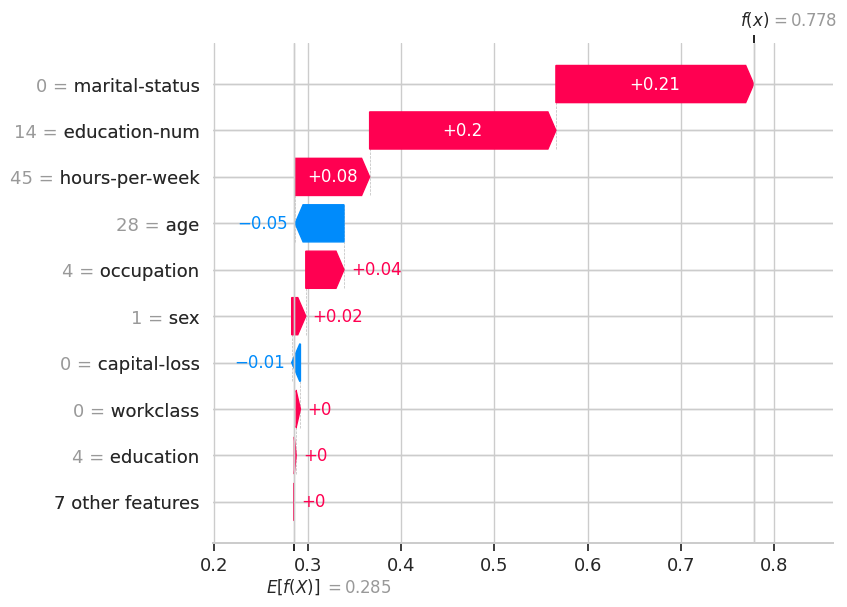

In [ ]:
shap.plots.waterfall(shap_values_noisy[0][:, 1])


Interpretation
Model confidence increased: After injecting noise + fairness adjustment, f(x) rose from 0.517 to 0.778, suggesting the model is now more confident in predicting high income for this sample.

Education became more influential: Its SHAP value rose from +0.14 to +0.20, showing a stronger correlation with positive outcome post-fairness.

Age’s negative effect reduced: The SHAP value of age moved from -0.10 to -0.05, indicating less penalty based on age — a good sign for reducing bias.

Less race-driven influence: Features indirectly tied to race (e.g., fnlwgt, race, etc.) no longer dominate the top contributors list — likely due to the Laplace noise and reweighing.

The fairness-aware pipeline with noisy ethnicity has redistributed influence toward more justifiable factors (like education-num and marital-status) and downplayed the impact of potentially biased features like age and race proxies.

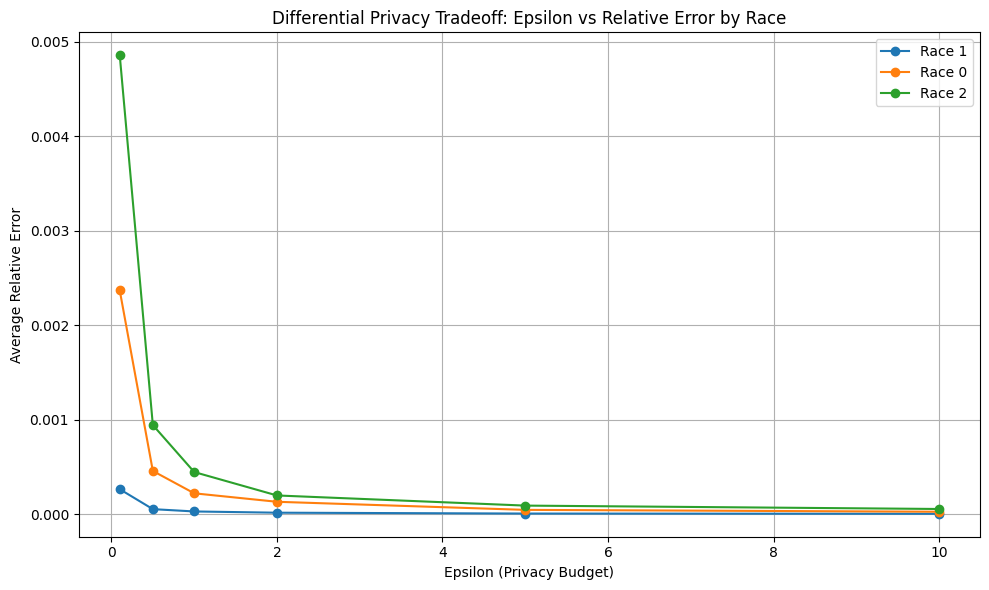

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Original counts for each race (example from your data)
original_counts = {
    1: 38903,
    0: 4226,
    2: 2093
}

# Range of epsilon values
epsilon_values = [0.1, 0.5, 1, 2, 5, 10]

# To store average relative errors for each epsilon
relative_errors = {race: [] for race in original_counts}

# Function to add Laplace noise and compute relative error
def get_noisy_count(original_count, epsilon):
    noise = np.random.laplace(loc=0.0, scale=1/epsilon)
    return original_count + noise

# Compute errors
for eps in epsilon_values:
    for race, original_count in original_counts.items():
        noisy_samples = [get_noisy_count(original_count, eps) for _ in range(100)]
        rel_errors = [abs(nc - original_count) / original_count for nc in noisy_samples]
        avg_rel_error = np.mean(rel_errors)
        relative_errors[race].append(avg_rel_error)

# Plotting
plt.figure(figsize=(10, 6))
for race, errors in relative_errors.items():
    plt.plot(epsilon_values, errors, marker='o', label=f"Race {race}")
plt.xlabel("Epsilon (Privacy Budget)")
plt.ylabel("Average Relative Error")
plt.title("Differential Privacy Tradeoff: Epsilon vs Relative Error by Race")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
